c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Asus\AppData\Local\Temp\ipykernel_11344\2447538363.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


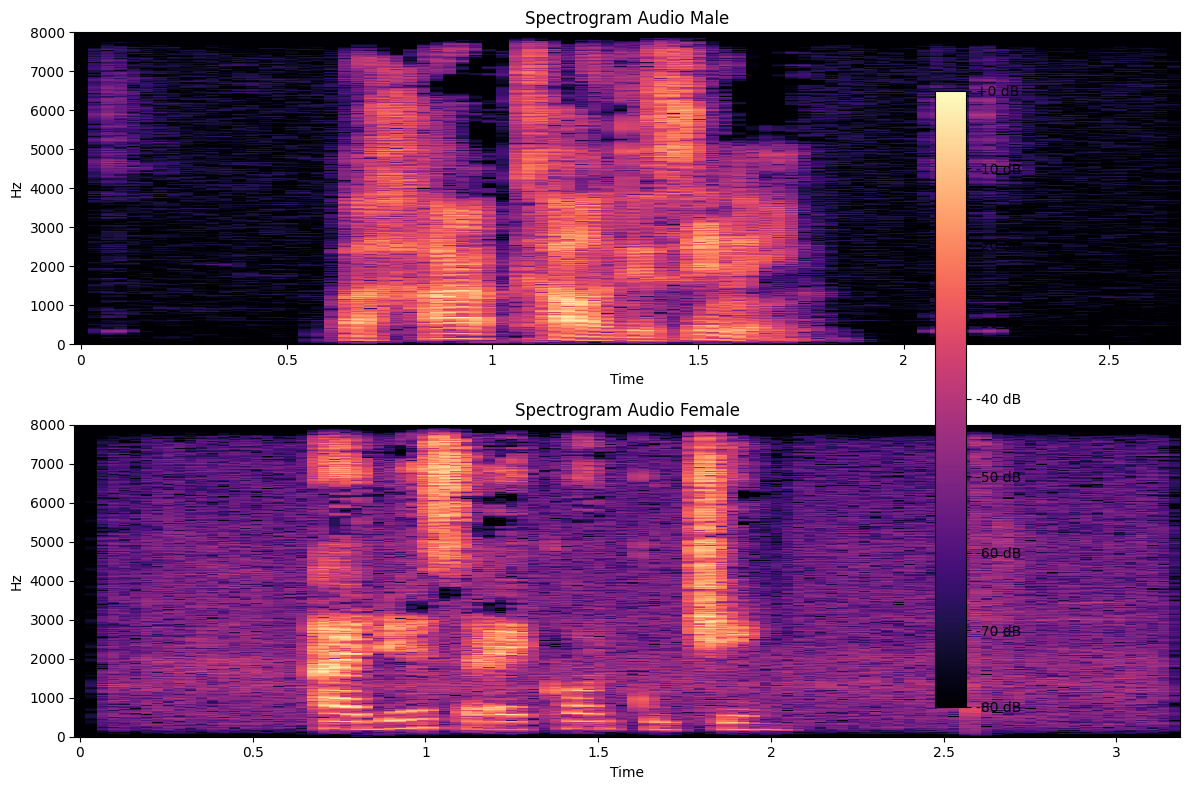

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ============================================================
# SPECTROGRAM MALE & FEMALE
# ============================================================

metadata_path = 'validated.tsv'
audio_folder = 'clips'

df = pd.read_csv(
    metadata_path,
    sep='\t'
)

# Ambil satu audio male
male_file = df[
    df["gender"] == "male_masculine"
]["path"].iloc[0]

# Ambil satu audio female
female_file = df[
    df["gender"] == "female_feminine"
]["path"].iloc[0]

male_path = os.path.join(
    audio_folder,
    male_file
)

female_path = os.path.join(
    audio_folder,
    female_file
)


def preprocess_audio(file_path):

    # Resampling 16 kHz + mono
    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # Pre-emphasis
    pre = 0.97

    y = np.append(
        y[0],
        y[1:] - pre * y[:-1]
    )

    return y, sr


# Preprocessing
y_male, sr_male = preprocess_audio(male_path)
y_female, sr_female = preprocess_audio(female_path)


# Spectrogram male
D_male = librosa.amplitude_to_db(
    np.abs(
        librosa.stft(y_male)
    ),
    ref=np.max
)

# Spectrogram female
D_female = librosa.amplitude_to_db(
    np.abs(
        librosa.stft(y_female)
    ),
    ref=np.max
)


# Visualisasi
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12, 8)
)

librosa.display.specshow(
    D_male,
    sr=sr_male,
    x_axis="time",
    y_axis="hz",
    ax=ax[0]
)

ax[0].set_title(
    "Spectrogram Audio Male"
)


librosa.display.specshow(
    D_female,
    sr=sr_female,
    x_axis="time",
    y_axis="hz",
    ax=ax[1]
)

ax[1].set_title(
    "Spectrogram Audio Female"
)


fig.colorbar(
    ax[0].collections[0],
    ax=ax,
    format="%+2.0f dB"
)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import os

# Cek file metadata
metadata_path = 'validated.tsv'
audio_folder = 'clips'

print("File yang ada:")
print(os.listdir('.'))

# Load dan cek struktur data
df = pd.read_csv(metadata_path, sep='\t')
print(f"\nKolom yang ada: {df.columns.tolist()}")
print(f"\nData gender yang ada: {df['gender'].unique()}")
print(f"Jumlah data female: {len(df[df['gender'] == 'female'])}")

# Cek path file
if len(df) > 0:
    print(f"\nSample path: {df.iloc[0]['path']}")

File yang ada:
['.venv', 'clips', 'distribusi_durasi_audio.ipynb', 'distribusi_label.ipynb', 'grafik_8_eksperimen_semua_metrik.png', 'grafik_tabel.html', 'grafik_tabel.ipynb', 'grid_confusion_matrix_8_eksperimen.png', 'm1-k1,13,3 fix.ipynb', 'm1-k1,13,3.ipynb', 'm1-k2,13,5.ipynb', 'm1-k3,13,7.ipynb', 'm1-k4,13,9.ipynb', 'm2-k1,18,3.ipynb', 'm2-k2,18,5.ipynb', 'm2-k3,18,7.ipynb', 'm2-k4,18,9.ipynb', 'm3-k1,20,3.ipynb', 'm3-k2,20,5.ipynb', 'm3-k3,20,7.ipynb', 'm3-k4,20,9.ipynb', 'm4-k1,24,3.ipynb', 'm4-k2,24,5.ipynb', 'm4-k3,24,7.ipynb', 'm4-k4,24,9.ipynb', 'spectogram.ipynb', 'validated.tsv', 'waveform.ipynb']

Kolom yang ada: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']

Data gender yang ada: <StringArray>
[nan, 'male_masculine', 'female_feminine']
Length: 3, dtype: str
Jumlah data female: 0

Sample path: common_voice_id_39599471.mp3
